Today, we will work on the Titanic Dataset used for a machine learning competition in [Kaggle](https://www.kaggle.com/competitions/titanic/data?select=train.csv).

#General Instructions:

You are assigned to clean and preprocess the data.

#About the Data

It is important to fully understand the datasets we are working on. Here's the data dictionary for the Titanic DataSet.

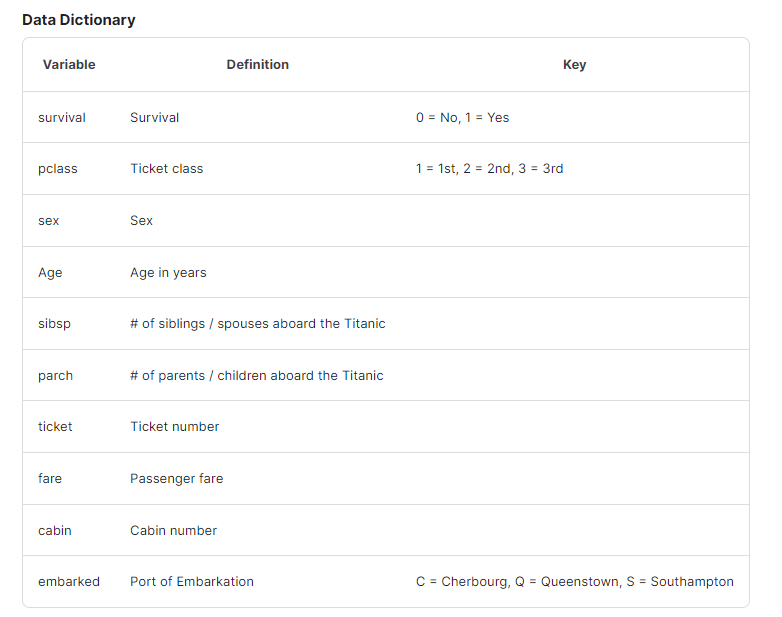

##**Variable Notes**


###pclass: A proxy for socio-economic status (SES)

1st = Upper<br>
2nd = Middle<br>
3rd = Lower<br>


###sibsp: The dataset defines family relations in this way...

Sibling = brother, sister, stepbrother, stepsister<br>
Spouse = husband, wife (mistresses and fiancés were ignored)<br>

###parch: The dataset defines family relations in this way...

Parent = mother, father <br>
Child = daughter, son, stepdaughter, stepson <br>
Some children travelled only with a nanny, therefore parch=0 for them. <br>



#1. IMPORT THE DATA

In [1]:
import pandas as pd

df = pd.read_csv('/content/TITANIC DATASET.csv')
display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#2. CATEGORIZE THE DUMMY VARIABLES


A dummy variable is a binary variable used to represent categorical data in statistical analysis, typically taking the value 0 or 1 to indicate the absence or presence of a characteristic or condition. In this case, replace them with their actual values.

##2.1 Convert Pclass

In [2]:
df['Pclass'] = df['Pclass'].map({1: 'Upper', 2: 'Middle', 3: 'Lower'})
display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,Lower,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,Upper,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,Lower,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,Upper,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,Lower,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


##2.2 Convert Survived

In [3]:
df['Survived'] = df['Survived'].map({0: 'Did not survive', 1: 'Survived'})
display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,Did not survive,Lower,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,Survived,Upper,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,Survived,Lower,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,Survived,Upper,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,Did not survive,Lower,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


##2.3 Convert Embarked

In [4]:
df['Embarked'] = df['Embarked'].map({'S': 'Southampton', 'C': 'Cherbourg', 'Q': 'Queenstown'})
display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,Did not survive,Lower,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,Southampton
1,2,Survived,Upper,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,Cherbourg
2,3,Survived,Lower,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,Southampton
3,4,Survived,Upper,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,Southampton
4,5,Did not survive,Lower,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,Southampton


#3. HANDLING MISSING VALUES

##3.1 Determine how many missing values are in our dataset.

In [5]:
missing_values = df.isnull().sum()
display(missing_values)

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


##3.2 Drop or Fill in the missing values with the following considerations in mind:

a. Cabin's missing value is a huge portion of the dataset. <br>
b. Age could be a good indicator or whether someone will survive this kind of disaster or not. <br>
c. We can't just assume someone's Port Embarkation. <br>

Now, as an analyst, decide if you want to drop columns/rows or fill in the missing values. Explain why you think your decision is good.


### ***Important note: find a way to handle the missing values one by one and do not just drop all.***

### .dropna() vs. .drop()


Use dropna() when you specifically want to remove rows or columns containing missing values.

Use drop() when you want to remove rows or columns based on specified labels, regardless of whether they contain missing values or not.




```
#.dropna() SYNTAX

DataFrame.dropna(axis=0, how='any', thresh=None, subset=None, inplace=False)

#.drop() SYNTAX

DataFrame.dropna(axis=0, how='any', thresh=None, subset=None, inplace=False)

```



In [13]:
if 'Cabin' in df.columns:
    df.drop('Cabin', axis=1, inplace=True)
    print("Cabin column dropped.")
else:
    print("Cabin column not found.")

print("Missing values after handling Cabin column:")
display(df.isnull().sum())

Cabin column not found.
Missing values after handling Cabin column:


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [11]:
# Replace missing 'Age' values with the median age
median_age = df['Age'].median()
df['Age'] = df['Age'].fillna(median_age)
display(df.isnull().sum())

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [12]:
# Drop rows where 'Embarked' is missing
df = df.dropna(subset=['Embarked'])
display(df.isnull().sum())

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0



Let's analyze each scenario:

a. Cabin's missing value is a huge portion of the dataset:

Decision: It's reasonable to consider dropping the entire "Cabin" column if the missing values represent a substantial portion of the dataset.
Explanation: Since a significant portion of the "Cabin" data is missing, imputing these missing values may not provide meaningful information. Additionally, if the cabin number is not deemed critical for the analysis, dropping the column reduces complexity without sacrificing much information.

b. Age could be a good indicator of survival:

Decision: Impute missing age values based on a method that preserves the relationship between age and survival.
Explanation: Age is potentially an important predictor of survival, so it's valuable to retain this variable in the analysis. Dropping rows with missing age values could lead to a significant loss of data and potentially bias the analysis. Therefore, imputing missing age values using methods such as mean, median, or regression imputation while considering its relationship with survival would be beneficial.

c. We can't just assume someone's Port Embarkation:

Decision: Drop rows with missing values for "Port Embarkation" since it's not feasible to accurately impute this information.
Explanation: Unlike age, which could be reasonably imputed, it's challenging to accurately infer someone's port of embarkation. Since it's a categorical variable without a clear substitute and assuming values might introduce bias, dropping rows with missing values for "Port Embarkation" would be a prudent choice.
In summary, the decision to drop or fill in missing values depends on the nature of the variable, the extent of missingness, and the importance of the variable for the analysis. In these scenarios, dropping the "Port Embarkation" column due to its unimputable nature and considering imputation for "Age" while dropping the "Cabin" column due to its high missingness seem to be reasonable strategies.

#4. Check if your datatypes are correct

In [14]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  889 non-null    int64  
 1   Survived     889 non-null    object 
 2   Pclass       889 non-null    object 
 3   Name         889 non-null    object 
 4   Sex          889 non-null    object 
 5   Age          889 non-null    float64
 6   SibSp        889 non-null    int64  
 7   Parch        889 non-null    int64  
 8   Ticket       889 non-null    object 
 9   Fare         889 non-null    float64
 10  Embarked     889 non-null    object 
dtypes: float64(2), int64(3), object(6)
memory usage: 83.3+ KB


None

#5. Measures

##5.1 What is the average age of the passengers

In [15]:
average_age = df['Age'].mean()
print(f"The average age of passengers is: {average_age:.2f} years")

The average age of passengers is: 29.32 years


##5.2 What is the maximum and minimum fare paid

In [16]:
max_fare = df['Fare'].max()
print(f"The maximum fare paid is: {max_fare:.2f}")

The maximum fare paid is: 512.33


In [17]:
min_fare = df['Fare'].min()
print(f"The minimum fare paid is: {min_fare:.2f}")

The minimum fare paid is: 0.00


##5.3 Are there more male or female?

In [20]:
gender_counts = df['Sex'].value_counts()
print("Number of passengers by gender:")
display(gender_counts)

Number of passengers by gender:


,count
Sex,
male,577
female,312


##5.4 How many passengers are in the upper class, middle class, and lower class.

In [21]:
pclass_counts = df['Pclass'].value_counts()
print("Number of passengers by Pclass:")
display(pclass_counts)

Number of passengers by Pclass:


,count
Pclass,
Lower,491
Upper,214
Middle,184


##5.5 How many passengers survived?

In [22]:
survived_counts = df['Survived'].value_counts()
print("Number of passengers by survival status:")
display(survived_counts)

Number of passengers by survival status:


,count
Survived,
Did not survive,549
Survived,340
